In [24]:

# --- Environment setup ---
# If running in a fresh environment, uncomment:
# %pip install datasets torch matplotlib

import re
import io
import json
import math
import random
from collections import Counter, defaultdict
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")

# Flip to False once you have internet access and want the real HF corpora.
OFFLINE_MODE = False

# Requested corpus size per class once running against the real HF datasets (OFFLINE_MODE=False).
# Set above 8,000 to leave headroom: loaders request this many *candidate* rows, but the final
# balanced count per class = min(deduped yield across all 4 sources), so a buffer above your
# actual target absorbs losses from de-duplication and length filtering.
TARGET_SAMPLES_PER_CLASS = 10000

LABELS = ["personal", "semantic", "working", "episodic"]
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}
IDX2LABEL = {i: l for l, i in LABEL2IDX.items()}

OUT_DIR = Path("artifacts")
OUT_DIR.mkdir(exist_ok=True)


Using device: mps



## Phase 1 — Data Aggregation

Each loader below pulls a real Hugging Face dataset, extracts the field that matches the
target linguistic profile, normalizes it, and returns a deduplicated list of clean strings.

**Design choice — stopwords are kept, not stripped.** Pronouns and function words
(`i`, `my`, `you`, `we`) are one of the strongest signals separating `personal`/`episodic`
(first-person) from `semantic` (third-person/objective) and `working` (imperative, no
grammatical subject). Removing them the way a generic text-classification pipeline would
throws away exactly the signal this classifier depends on.


In [25]:

# --- Text normalization utilities ---

MIN_CHARS, MAX_CHARS = 8, 300

def clean_text(t: str) -> str:
    if t is None:
        return ""
    t = t.replace("_comma_", ",")          # empathetic_dialogues artifact
    t = re.sub(r"\s+", " ", t).strip()
    return t

def is_valid(t: str) -> bool:
    return bool(t) and MIN_CHARS <= len(t) <= MAX_CHARS


In [26]:
# Make sure to run: pip install datasets
from datasets import DatasetDict, concatenate_datasets, load_dataset


def clean_text(text):
    """Basic helper to ensure string sanitation."""
    if not text:
        return ""
    return str(text).strip().replace("\n", " ")


def is_valid(text):
    """Filters out empty or overly short sentences."""
    return len(text.split()) > 3


def load_all_splits(dataset_name, **kwargs):
    ds = load_dataset(dataset_name, **kwargs)
    if isinstance(ds, DatasetDict):
        splits = list(ds.values())
        if len(splits) == 1:
            return splits[0]
        return concatenate_datasets(splits)
    return ds


def load_personal_memory(limit=1000000):
    '''Personal Memory: First-person identity/trait statements.
    Source: bavard/personachat_truecased -> 'personality' field'''
    # This dataset requires its repo script to be trusted before loading.
    ds = load_all_splits("bavard/personachat_truecased", trust_remote_code=True)
    texts, seen = [], set()
    for row in ds:
        for sent in row["personality"]:
            t = clean_text(sent)
            if is_valid(t) and t not in seen:
                seen.add(t)
                texts.append(t)
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_semantic_memory(limit=1000000):
    '''Semantic Memory: Objective, encyclopedic facts & definitions.
    Source: microsoft/wiki_qa -> 'answer' field (Wikipedia snippets).'''
    ds = load_all_splits("microsoft/wiki_qa", trust_remote_code=True)
    texts, seen = [], set()
    for row in ds:
        t = clean_text(row["answer"])
        if is_valid(t) and t not in seen:
            seen.add(t)
            texts.append(t)
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_working_memory(limit=1000000):
    '''Working Memory: Immediate, task-oriented commands.
    Source: tatsu-lab/alpaca -> 'instruction' field (imperative directives).'''
    ds = load_all_splits("tatsu-lab/alpaca", trust_remote_code=True)
    texts, seen = [], set()
    for row in ds:
        t = clean_text(row["instruction"])
        if is_valid(t) and t not in seen:
            seen.add(t)
            texts.append(t)
        if len(texts) >= limit:
            break
    return texts[:limit]


def load_episodic_memory(limit=1000000):
    '''Episodic Memory: Past-tense, situational conversational events.
    Source: facebook/empathetic_dialogues -> 'prompt' field.'''
    try:
        ds = load_all_splits("facebook/empathetic_dialogues", trust_remote_code=True)
        texts, seen = [], set()
        for row in ds:
            t = clean_text(row["prompt"])
            if is_valid(t) and t not in seen:
                seen.add(t)
                texts.append(t)
            if len(texts) >= limit:
                break
        return texts[:limit]
    except Exception as exc:
        print(f"Falling back to direct empathetic_dialogues download ({type(exc).__name__}): {exc}")
        import csv
        import io as _io
        import os
        import ssl
        import tarfile
        import tempfile
        import urllib.request

        archive_path = OUT_DIR / "empatheticdialogues.tar.gz"
        if not archive_path.exists():
            url = "https://dl.fbaipublicfiles.com/parlai/empatheticdialogues/empatheticdialogues.tar.gz"
            ctx = ssl._create_unverified_context()
            fd, tmp_path = tempfile.mkstemp(suffix=".tar.gz")
            os.close(fd)
            try:
                with urllib.request.urlopen(url, context=ctx) as resp, open(tmp_path, "wb") as out:
                    while True:
                        chunk = resp.read(1024 * 1024)
                        if not chunk:
                            break
                        out.write(chunk)
                os.replace(tmp_path, archive_path)
            finally:
                if os.path.exists(tmp_path):
                    os.remove(tmp_path)

        texts, seen = [], set()
        with tarfile.open(archive_path, "r:gz") as tar:
            csv_members = sorted(
                [m for m in tar.getmembers() if m.name.endswith(".csv")],
                key=lambda m: m.name,
            )
            for member_info in csv_members:
                member = tar.extractfile(member_info)
                if member is None:
                    continue
                reader = csv.DictReader(_io.TextIOWrapper(member, encoding="utf-8"))
                for row in reader:
                    t = clean_text(row.get("prompt", ""))
                    if is_valid(t) and t not in seen:
                        seen.add(t)
                        texts.append(t)
                    if len(texts) >= limit:
                        break
                if len(texts) >= limit:
                    break
        return texts[:limit]


HF_LOADERS = {
    "personal": load_personal_memory,
    "semantic": load_semantic_memory,
    "working": load_working_memory,
    "episodic": load_episodic_memory,
}


In [27]:

# --- Offline synthetic fallback (only used when OFFLINE_MODE = True) ---
# Templated generators that mimic each source's linguistic profile, so the rest of the
# notebook (vectorizer, MLP, training, evaluation) can be exercised without internet access.

def _build_synthetic_corpus(seed=SEED, n_per_class=500):
    rng = random.Random(seed)

    personal_templates = [
        "I am a {adj} person who loves {hobby}.",
        "I have {n} {pet}s and I adore them.",
        "My favorite {thing} is {value}.",
        "I work as a {job} and I am proud of it.",
        "I grew up in {place} and it shaped who I am.",
        "I consider myself {adj} and {adj2}.",
    ]
    semantic_templates = [
        "The {concept} is defined as the {def_}.",
        "{Concept} refers to a process by which {process}.",
        "In physics, {concept} describes the relationship between {a} and {b}.",
        "The capital of {country} is {city}.",
        "{Concept} was first described in {year} by researchers studying {field}.",
        "A {concept} is a type of {category} found in {field}.",
    ]
    working_templates = [
        "Set a reminder for {time}.",
        "Book a table for {n} at {place}.",
        "Turn off the {device} in the living room.",
        "Add {item} to my shopping list.",
        "Schedule a meeting with {person} tomorrow at {time}.",
        "Find the nearest {place} and send me directions.",
    ]
    episodic_templates = [
        "Yesterday I went to the {place} and met {person}.",
        "Last week I was feeling {adj} after the {event}.",
        "We celebrated my {relation}'s birthday at {place} last month.",
        "I remember when I first {action} back in {year}.",
        "During the trip, I visited {place} and it was {adj}.",
        "This morning I {action} before heading to work.",
        "Last summer I {action} with {person} in {place}.",
        "A few months ago I {action} and it felt {adj}.",
        "Back in {year} I {action} while visiting {place}.",
        "Earlier this year I {action} with my {relation}.",
    ]
    fillers = {
        "adj": ["curious","happy","nervous","excited","calm","tired","anxious","confident"],
        "adj2": ["patient","stubborn","optimistic","organized"],
        "hobby": ["hiking","painting","chess","cooking","reading","gardening"],
        "n": ["two","three","four","five","six"],
        "pet": ["dog","cat","bird","fish","rabbit"],
        "thing": ["color","food","season","movie","book"],
        "value": ["blue","pizza","autumn","a sci-fi film","a mystery novel"],
        "job": ["teacher","engineer","nurse","artist","chef"],
        "place": ["Paris","the mountains","a small town","New York","the beach","the library","a cafe"],
        "concept": ["photosynthesis","gravity","inflation","democracy","osmosis","entropy"],
        "Concept": ["Photosynthesis","Gravity","Inflation","Democracy","Osmosis","Entropy"],
        "def_": ["conversion of light into chemical energy","force attracting masses",
                 "rise in prices over time","measure of disorder in a system"],
        "process": ["plants convert sunlight into energy","cells divide",
                    "water moves across a membrane","heat flows between two bodies"],
        "a": ["mass","voltage","supply","pressure"],
        "b": ["acceleration","current","demand","volume"],
        "category": ["organelle","economic indicator","political system","physical law"],
        "country": ["France","Japan","Germany","Brazil","Canada"],
        "city": ["Paris","Tokyo","Berlin","Brasilia","Ottawa"],
        "year": ["1928","1953","1687","2001","1867"],
        "field": ["genetics","chemistry","astronomy","economics"],
        "time": ["3pm","9am","noon","6:30pm","8am"],
        "device": ["lights","TV","speaker","heater","fan"],
        "item": ["milk","eggs","bread","coffee","rice"],
        "person": ["Sarah","the client","Dr. Lee","my manager","the team"],
        "event": ["exam","interview","storm","deadline"],
        "relation": ["sister","brother","mom","friend","cousin"],
        "action": ["rode a bike","cooked dinner","flew on a plane","went for a run","read a book"],
    }

    def fill(t):
        out = t
        for k, vals in fillers.items():
            if "{" + k + "}" in out:
                out = out.replace("{" + k + "}", rng.choice(vals))
        return out

    def gen(templates, n):
        return [fill(rng.choice(templates)) for _ in range(n)]

    return {
        "personal": gen(personal_templates, n_per_class),
        "semantic": gen(semantic_templates, n_per_class),
        "working": gen(working_templates, n_per_class),
        "episodic": gen(episodic_templates, n_per_class),
    }


In [28]:

# --- Build the unified corpus ---

if OFFLINE_MODE:
    print("OFFLINE_MODE=True -> using synthetic stand-in corpus (no internet required).")
    raw_data = _build_synthetic_corpus(n_per_class=600)
else:
    print("OFFLINE_MODE=False -> pulling real corpora from the Hugging Face Hub...")
    try:
        raw_data = {label: fn(limit=TARGET_SAMPLES_PER_CLASS) for label, fn in HF_LOADERS.items()}
    except Exception as exc:
        print(f"HF download failed ({type(exc).__name__}): {exc}")
        print("Falling back to synthetic stand-in corpus so the notebook can continue.")
        fallback_builder = globals().get("_build_synthetic_corpus")
        if fallback_builder is None:
            def fallback_builder(seed=SEED, n_per_class=600):
                rng = random.Random(seed)
                personal = [
                    "I am a {adj} person who loves {hobby}.",
                    "I have {n} {pet}s and I adore them.",
                    "My favorite {thing} is {value}.",
                    "I work as a {job} and I am proud of it.",
                    "I grew up in {place} and it shaped who I am.",
                    "I consider myself {adj} and {adj2}.",
                ]
                semantic = [
                    "The {concept} is defined as the {def_}.",
                    "{Concept} refers to a process by which {process}.",
                    "In physics, {concept} describes the relationship between {a} and {b}.",
                    "The capital of {country} is {city}.",
                    "{Concept} was first described in {year} by researchers studying {field}.",
                    "A {concept} is a type of {category} found in {field}.",
                ]
                working = [
                    "Set a reminder for {time}.",
                    "Book a table for {n} at {place}.",
                    "Turn off the {device} in the living room.",
                    "Add {item} to my shopping list.",
                    "Schedule a meeting with {person} tomorrow at {time}.",
                    "Find the nearest {place} and send me directions.",
                ]
                episodic = [
                    "Yesterday I went to the {place} and met {person}.",
                    "Last week I was feeling {adj} after the {event}.",
                    "We celebrated my {relation}'s birthday at {place} last month.",
                    "I remember when I first {action} back in {year}.",
                    "During the trip, I visited {place} and it was {adj}.",
                    "This morning I {action} before heading to work.",
                    "Last summer I {action} with {person} in {place}.",
                    "A few months ago I {action} and it felt {adj}.",
                    "Back in {year} I {action} while visiting {place}.",
                    "Earlier this year I {action} with my {relation}.",
                ]
                fillers = {
                    "adj": ["curious", "happy", "nervous", "excited", "calm", "tired", "anxious", "confident"],
                    "adj2": ["patient", "stubborn", "optimistic", "organized"],
                    "hobby": ["hiking", "painting", "chess", "cooking", "reading", "gardening"],
                    "n": ["two", "three", "four", "five", "six"],
                    "pet": ["dog", "cat", "bird", "fish", "rabbit"],
                    "thing": ["color", "food", "season", "movie", "book"],
                    "value": ["blue", "pizza", "autumn", "a sci-fi film", "a mystery novel"],
                    "job": ["teacher", "engineer", "nurse", "artist", "chef"],
                    "place": ["Paris", "the mountains", "a small town", "New York", "the beach", "the library", "a cafe"],
                    "concept": ["photosynthesis", "gravity", "inflation", "democracy", "osmosis", "entropy"],
                    "Concept": ["Photosynthesis", "Gravity", "Inflation", "Democracy", "Osmosis", "Entropy"],
                    "def_": ["conversion of light into chemical energy", "force attracting masses", "rise in prices over time", "measure of disorder in a system"],
                    "process": ["plants convert sunlight into energy", "cells divide", "water moves across a membrane", "heat flows between two bodies"],
                    "a": ["mass", "voltage", "supply", "pressure"],
                    "b": ["acceleration", "current", "demand", "volume"],
                    "category": ["organelle", "economic indicator", "political system", "physical law"],
                    "country": ["France", "Japan", "Germany", "Brazil", "Canada"],
                    "city": ["Paris", "Tokyo", "Berlin", "Brasilia", "Ottawa"],
                    "year": ["1928", "1953", "1687", "2001", "1867"],
                    "field": ["genetics", "chemistry", "astronomy", "economics"],
                    "time": ["3pm", "9am", "noon", "6:30pm", "8am"],
                    "device": ["lights", "TV", "speaker", "heater", "fan"],
                    "item": ["milk", "eggs", "bread", "coffee", "rice"],
                    "person": ["Sarah", "the client", "Dr. Lee", "my manager", "the team"],
                    "event": ["exam", "interview", "storm", "deadline"],
                    "relation": ["sister", "brother", "mom", "friend", "cousin"],
                    "action": ["rode a bike", "cooked dinner", "flew on a plane", "went for a run", "read a book"],
                }
                def fill(template):
                    result = template
                    for key, values in fillers.items():
                        if "{" + key + "}" in result:
                            result = result.replace("{" + key + "}", rng.choice(values))
                    return result
                def gen(templates, n):
                    return [fill(rng.choice(templates)) for _ in range(n)]
                return {
                    "personal": gen(personal, n_per_class),
                    "semantic": gen(semantic, n_per_class),
                    "working": gen(working, n_per_class),
                    "episodic": gen(episodic, n_per_class),
                }
        raw_data = fallback_builder(n_per_class=600)

for label, texts in raw_data.items():
    print(f"{label:10s}: {len(texts)} raw samples")

# Balance classes by undersampling to the smallest class, so the MLP isn't biased
# toward whichever HF source happened to be largest.
min_count = min(len(v) for v in raw_data.values())
print(f"\nBalancing all classes to {min_count} samples each")

rng = random.Random(SEED)
records = []
for label, texts in raw_data.items():
    sampled = rng.sample(texts, min_count)
    records.extend({"text": t, "label": label} for t in sampled)

rng.shuffle(records)
print(f"Total unified corpus: {len(records)} records")

with open(OUT_DIR / "corpus.json", "w") as f:
    json.dump(records, f, indent=2)


OFFLINE_MODE=False -> pulling real corpora from the Hugging Face Hub...


Repo card metadata block was not found. Setting CardData to empty.


Falling back to direct empathetic_dialogues download (FileNotFoundError): https://dl.fbaipublicfiles.com/parlai/empatheticdialogues/empatheticdialogues.tar.gz
personal  : 6201 raw samples
semantic  : 10000 raw samples
working   : 10000 raw samples
episodic  : 10000 raw samples

Balancing all classes to 6201 samples each
Total unified corpus: 24804 records


In [29]:

# --- Stratified train / val / test split (pure Python, no sklearn) ---

def stratified_split(records, val_frac=0.15, test_frac=0.15, seed=SEED):
    by_label = defaultdict(list)
    for r in records:
        by_label[r["label"]].append(r)

    train, val, test = [], [], []
    split_rng = random.Random(seed)
    for label, items in by_label.items():
        split_rng.shuffle(items)
        n = len(items)
        n_val = int(n * val_frac)
        n_test = int(n * test_frac)
        val.extend(items[:n_val])
        test.extend(items[n_val:n_val + n_test])
        train.extend(items[n_val + n_test:])

    split_rng.shuffle(train); split_rng.shuffle(val); split_rng.shuffle(test)
    return train, val, test

train_records, val_records, test_records = stratified_split(records)
print(f"train={len(train_records)}  val={len(val_records)}  test={len(test_records)}")


train=17364  val=3720  test=3720


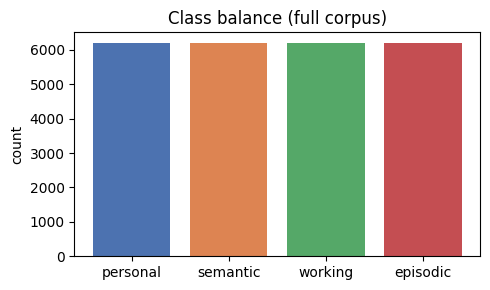


Sample records:
  [personal  ] My husband works at a telecom.
  [semantic  ] Per Guyton's illustration, of the 15 litres of extracellular fluid, plasma volume averages 3 litres.
  [working   ] Identify the landmark built in 1060 near Athens.
  [episodic  ] I recently found out the girl I am very attracted to might not like me in the same way. This makes me sad because we get along incredibly well.


In [30]:

# --- Sanity check: class balance + example rows ---

fig, ax = plt.subplots(figsize=(5, 3))
counts = [sum(1 for r in records if r["label"] == l) for l in LABELS]
ax.bar(LABELS, counts, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
ax.set_title("Class balance (full corpus)")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

print("\nSample records:")
for label in LABELS:
    example = next(r["text"] for r in records if r["label"] == label)
    print(f"  [{label:10s}] {example}")



## Phase 2 — Custom TF-IDF Vectorizer (pure Python, no sklearn)

Standard TF-IDF, built from scratch with `re` + `collections.Counter` + `math.log`:

- **Tokenizer**: lowercase word tokens + bigrams (`use_bigrams=True`) — bigrams capture
  short imperative phrases like `"turn_off"` or `"schedule_a"` that unigrams alone miss.
- **Vocabulary pruning**: `min_df` / `max_df_ratio` drop terms that are too rare (noise) or
  too common (uninformative across all four classes), then keep the top `max_features` by
  document frequency.
- **Weighting**: sublinear TF (`1 + log(tf)`) dampens the effect of a term repeated many
  times in one document, combined with smoothed IDF (`ln((1+N)/(1+df)) + 1`).
- **Normalization**: each vector is L2-normalized, which is what lets a plain dot product
  behave like cosine similarity and keeps the MLP's input scale stable across documents of
  very different lengths.


In [ ]:

TOKEN_RE = re.compile(r"[a-zA-Z0-9:_/-]+")

def tokenize(text: str, use_bigrams: bool = True):
    tokens = [t.lower() for t in TOKEN_RE.findall(text)]
    if use_bigrams:
        bigrams = [f"{a}_{b}" for a, b in zip(tokens, tokens[1:])]
        return tokens + bigrams
    return tokens


class TFIDFVectorizer:
    '''Deterministic TF-IDF vectorizer implemented with base Python only
    (re, collections.Counter, math) — no scikit-learn.'''

    def __init__(self, max_features=10000, min_df=2, max_df_ratio=0.9,
                 use_bigrams=True, sublinear_tf=True):
        self.max_features = max_features
        self.min_df = min_df
        self.max_df_ratio = max_df_ratio
        self.use_bigrams = use_bigrams
        self.sublinear_tf = sublinear_tf
        self.vocab_ = {}   # token -> column index
        self.idf_ = {}     # token -> idf weight

    def fit(self, texts):
        n_docs = len(texts)
        df = Counter()
        for text in texts:
            df.update(set(tokenize(text, self.use_bigrams)))

        max_df_count = self.max_df_ratio * n_docs
        candidates = [
            (tok, c) for tok, c in df.items()
            if self.min_df <= c <= max_df_count
        ]
        # Keep the most broadly-attested terms up to the feature cap.
        candidates.sort(key=lambda x: -x[1])
        candidates = candidates[: self.max_features]

        self.vocab_ = {tok: i for i, (tok, _) in enumerate(candidates)}
        self.idf_ = {
            tok: math.log((1 + n_docs) / (1 + c)) + 1.0
            for tok, c in candidates
        }
        return self

    def _vectorize_one(self, text):
        tokens = tokenize(text, self.use_bigrams)
        counts = Counter(t for t in tokens if t in self.vocab_)
        vec = torch.zeros(len(self.vocab_))
        for tok, c in counts.items():
            tf = 1 + math.log(c) if self.sublinear_tf else float(c)
            vec[self.vocab_[tok]] = tf * self.idf_[tok]
        norm = torch.norm(vec, p=2)
        if norm > 0:
            vec = vec / norm
        return vec

    def transform(self, texts):
        return torch.stack([self._vectorize_one(t) for t in texts])

    def fit_transform(self, texts):
        self.fit(texts)
        return self.transform(texts)

    def save(self, path):
        with open(path, "w") as f:
            json.dump({
                "vocab": self.vocab_,
                "idf": self.idf_,
                "max_features": self.max_features,
                "use_bigrams": self.use_bigrams,
                "sublinear_tf": self.sublinear_tf,
            }, f)

    @classmethod
    def load(cls, path):
        with open(path) as f:
            data = json.load(f)
        vec = cls(max_features=data["max_features"],
                   use_bigrams=data["use_bigrams"],
                   sublinear_tf=data["sublinear_tf"])
        vec.vocab_ = data["vocab"]
        vec.idf_ = data["idf"]
        return vec


In [32]:

vectorizer = TFIDFVectorizer(max_features=10000, min_df=2, max_df_ratio=0.9,
                              use_bigrams=True, sublinear_tf=True)

X_train = vectorizer.fit_transform([r["text"] for r in train_records])
y_train = torch.tensor([LABEL2IDX[r["label"]] for r in train_records], dtype=torch.long)

X_val = vectorizer.transform([r["text"] for r in val_records])
y_val = torch.tensor([LABEL2IDX[r["label"]] for r in val_records], dtype=torch.long)

X_test = vectorizer.transform([r["text"] for r in test_records])
y_test = torch.tensor([LABEL2IDX[r["label"]] for r in test_records], dtype=torch.long)

vocab_size = len(vectorizer.vocab_)
sparsity = (X_train == 0).float().mean().item()
print(f"Vocabulary size: {vocab_size}")
print(f"X_train shape:   {tuple(X_train.shape)}")
print(f"Sparsity:        {sparsity:.2%} of entries are zero")

vectorizer.save(OUT_DIR / "tfidf_vectorizer.json")


Vocabulary size: 10000
X_train shape:   (17364, 10000)
Sparsity:        99.83% of entries are zero



## PyTorch `Dataset` / `DataLoader`


In [33]:

class MemoryTextDataset(Dataset):
    def __init__(self, X: torch.Tensor, y: torch.Tensor):
        self.X, self.y = X, y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 128

train_loader = DataLoader(MemoryTextDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(MemoryTextDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(MemoryTextDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)



## Phase 2 — The MLP Classifier (pure PyTorch)

A small feed-forward network: `Linear -> BatchNorm -> ReLU -> Dropout`, stacked twice,
then a final `Linear` to 4 logits. `BatchNorm1d` speeds up convergence on TF-IDF's
high-dimensional, sparsity-heavy input; `Dropout` plus `weight_decay` in the optimizer
keep it from memorizing lexical quirks of any one HF source.


In [ ]:

class MemoryClassifierMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(1024, 512,256), num_classes=4, dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model = MemoryClassifierMLP(input_dim=vocab_size, hidden_dims=(512, 128),
                             num_classes=len(LABELS), dropout=0.3).to(DEVICE)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")


MemoryClassifierMLP(
  (net): Sequential(
    (0): Linear(in_features=10000, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=4, bias=True)
  )
)

Total trainable parameters: 5,187,972



## Training loop — early stopping + LR scheduling

Standard supervised training: `CrossEntropyLoss` + `AdamW`, with `ReduceLROnPlateau`
halving the learning rate when validation loss stalls, and early stopping that restores
the best-validation-loss weights once patience is exhausted.


In [35]:

def evaluate_loss_acc(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(1) == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

EPOCHS = 40
PATIENCE = 40

best_val_loss = float("inf")
best_state = None
patience_ctr = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)

    train_loss, train_acc = running_loss / total, correct / total
    val_loss, val_acc = evaluate_loss_acc(model, val_loader)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d} | train_loss {train_loss:.4f} acc {train_acc:.4f} "
          f"| val_loss {val_loss:.4f} acc {val_acc:.4f}")

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
            break

model.load_state_dict(best_state)


Epoch 01 | train_loss 0.2433 acc 0.9210 | val_loss 0.1153 acc 0.9591
Epoch 02 | train_loss 0.0407 acc 0.9876 | val_loss 0.1217 acc 0.9573
Epoch 03 | train_loss 0.0152 acc 0.9961 | val_loss 0.1291 acc 0.9602
Epoch 04 | train_loss 0.0084 acc 0.9980 | val_loss 0.1360 acc 0.9605
Epoch 05 | train_loss 0.0042 acc 0.9991 | val_loss 0.1326 acc 0.9629
Epoch 06 | train_loss 0.0026 acc 0.9997 | val_loss 0.1333 acc 0.9629
Epoch 07 | train_loss 0.0019 acc 0.9997 | val_loss 0.1368 acc 0.9618
Epoch 08 | train_loss 0.0019 acc 0.9995 | val_loss 0.1366 acc 0.9640
Epoch 09 | train_loss 0.0013 acc 0.9998 | val_loss 0.1396 acc 0.9634
Epoch 10 | train_loss 0.0013 acc 0.9998 | val_loss 0.1405 acc 0.9629
Epoch 11 | train_loss 0.0013 acc 0.9997 | val_loss 0.1404 acc 0.9629
Epoch 12 | train_loss 0.0013 acc 0.9997 | val_loss 0.1400 acc 0.9626
Epoch 13 | train_loss 0.0013 acc 0.9997 | val_loss 0.1417 acc 0.9632
Epoch 14 | train_loss 0.0011 acc 0.9998 | val_loss 0.1422 acc 0.9632
Epoch 15 | train_loss 0.0010 acc 0

<All keys matched successfully>

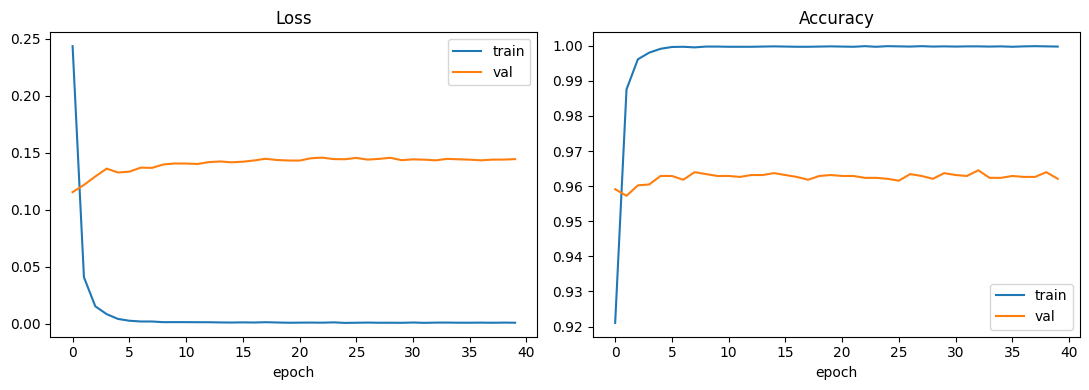

In [36]:

# --- Training curves ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()

plt.tight_layout()
plt.show()



## Evaluation — manual metrics (no sklearn)

Confusion matrix, per-class precision/recall/F1, and overall accuracy, all computed with
plain `torch` tensor operations.


In [37]:

def confusion_matrix(y_true, y_pred, num_classes):
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm


def classification_report(y_true, y_pred, labels):
    num_classes = len(labels)
    cm = confusion_matrix(y_true, y_pred, num_classes)
    report = {}
    for i, label in enumerate(labels):
        tp = cm[i, i].item()
        fp = cm[:, i].sum().item() - tp
        fn = cm[i, :].sum().item() - tp
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        support = cm[i, :].sum().item()
        report[label] = {"precision": precision, "recall": recall, "f1": f1, "support": support}
    accuracy = torch.diag(cm).sum().item() / cm.sum().item()
    return report, accuracy, cm


model.eval()
with torch.no_grad():
    test_logits = model(X_test.to(DEVICE))
    test_preds = test_logits.argmax(1).cpu()

report, accuracy, cm = classification_report(y_test.tolist(), test_preds.tolist(), LABELS)

print(f"Test accuracy: {accuracy:.4f}\n")
print(f"{'class':10s} {'precision':>10s} {'recall':>10s} {'f1':>10s} {'support':>10s}")
for label, m in report.items():
    print(f"{label:10s} {m['precision']:10.3f} {m['recall']:10.3f} {m['f1']:10.3f} {m['support']:10d}")


Test accuracy: 0.9546

class       precision     recall         f1    support
personal        0.947      0.917      0.932        930
semantic        0.968      0.978      0.973        930
working         0.982      0.975      0.978        930
episodic        0.923      0.947      0.935        930


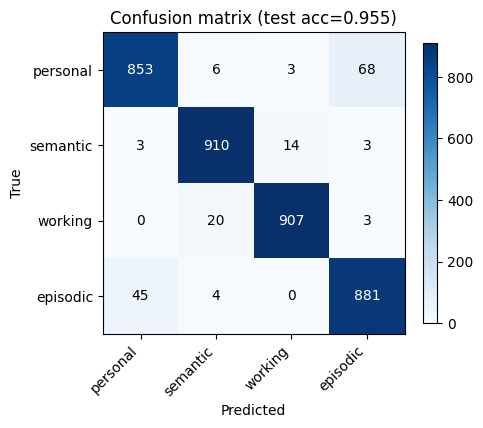

In [38]:

# --- Confusion matrix heatmap ---
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm.numpy(), cmap="Blues")
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix (test acc={accuracy:.3f})")

for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        val = cm[i, j].item()
        color = "white" if val > cm.max().item() / 2 else "black"
        ax.text(j, i, str(val), ha="center", va="center", color=color)

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()



## Save artifacts

The trained model weights, the TF-IDF vocabulary/IDF table, and the label map are saved
so the classifier can be loaded standalone by the downstream Phase 3 (SPO extraction /
storage routing) and Phase 4 (conflict resolution) components without retraining.


In [39]:

torch.save(model.state_dict(), OUT_DIR / "memory_classifier_mlp.pt")
vectorizer.save(OUT_DIR / "tfidf_vectorizer.json")
with open(OUT_DIR / "label_map.json", "w") as f:
    json.dump({"labels": LABELS, "label2idx": LABEL2IDX}, f, indent=2)

# Also persist the architecture hyperparams needed to reconstruct the model at load time.
with open(OUT_DIR / "model_config.json", "w") as f:
    json.dump({
        "input_dim": vocab_size,
        "hidden_dims": [512, 128],
        "num_classes": len(LABELS),
        "dropout": 0.3,
    }, f, indent=2)

print("Saved to:", [p.name for p in OUT_DIR.iterdir()])


Saved to: ['corpus.json', 'memory_classifier_mlp.pt', 'empatheticdialogues.tar.gz', 'label_map.json', 'tfidf_vectorizer.json', 'model_config.json']



## Inference demo — classify & route

A single deterministic function that takes raw text, vectorizes it with the fitted
TF-IDF vectorizer, runs it through the trained MLP, and returns the predicted memory
type plus a softmax confidence score. This confidence score is exactly the signal Phase 4
(adversarial conflict resolution) will use downstream to decide whether a new fact should
overwrite, supersede, or be rejected against an existing memory entry.


In [ ]:

@torch.no_grad()
def classify_and_route(text: str, model=model, vectorizer=vectorizer):
    model.eval()
    vec = vectorizer.transform([text]).to(DEVICE)
    logits = model(vec)
    probs = torch.softmax(logits, dim=1).squeeze(0)
    pred_idx = int(probs.argmax())
    return {
        "text": text,
        "predicted_memory": IDX2LABEL[pred_idx],
        "confidence": round(probs[pred_idx].item(), 4),
        "distribution": {IDX2LABEL[i]: round(p.item(), 4) for i, p in enumerate(probs)},
    }


demo_examples = [
    "I prefer studying in the early morning before anyone else is awake.",
    "Water freezes at 0 degrees Celsius.",
    "Remind me to submit my assignment before 11:59 PM tonight.",
    "Last weekend I visited my grandparents and helped them plant flowers.",

    "I enjoy spicy food more than sweet desserts.",
    "The Pacific Ocean is the largest ocean on Earth.",
    "Remember that my Zoom meeting starts in 20 minutes.",
    "I celebrated my birthday with a small group of close friends last year.",

    "I am allergic to peanuts.",
    "The capital of Australia is Canberra.",
    "Keep track of the three articles I need to read today.",
    "During winter break I learned how to ski for the first time.",

    "I usually drink coffee instead of tea in the morning.",
    "Photosynthesis converts sunlight into chemical energy.",
    "Don't let me forget to buy groceries after work.",
    "Last month I attended a live jazz concert downtown.",

    "I have two younger siblings.",
    "The Great Wall of China was built over many centuries.",
    "Remember that table 7 ordered the vegetarian pasta.",
    "I met my childhood best friend at a reunion last summer.",

    "I like solving logic puzzles on weekends.",
    "Venus is the hottest planet in the solar system.",
    "The password for today's Wi-Fi is written on the whiteboard.",
    "Yesterday I accidentally left my backpack on the bus but got it back.",

    "I prefer handwritten notes over digital notes.",
    "The human body has 206 bones.",
    "Schedule a reminder to water the plants every Friday.",
    "Last fall I volunteered at a local food bank.",

    "I enjoy rainy weather.",
    "Mount Everest is the tallest mountain above sea level.",
    "Remember that Alice is bringing dessert to tonight's dinner.",
    "I watched the northern lights during a trip to Iceland.",

    "I dislike horror movies.",
    "The speed of light is approximately 299,792 kilometers per second.",
    "Move the meeting from 2 PM to 3 PM.",
    "When I was ten years old I broke my arm riding a bicycle.",

    "I always carry a reusable water bottle.",
    "The Amazon rainforest produces a significant amount of Earth's oxygen.",
    "Don't forget to email the project proposal before noon.",
    "I once got caught in a thunderstorm while hiking.",

    "I enjoy listening to classical music while studying.",
    "An octagon has eight sides.",
    "Remember that the spare key is inside the kitchen drawer.",
    "Last Christmas my family baked cookies together.",

    "I prefer Android phones over iPhones.",
    "Sharks are fish, not mammals.",
    "Call the mechanic tomorrow morning.",
    "I visited the Grand Canyon during a family road trip.",

    "I wear glasses when reading.",
    "The chemical symbol for sodium is Na.",
    "The package should arrive sometime this afternoon.",
    "Last year I completed my first half marathon.",

    "I enjoy playing board games with friends.",
    "Honey never truly spoils if stored properly.",
    "Save the document before closing the program.",
    "I accidentally spilled coffee on my laptop during finals week.",

    "I prefer mountains over beaches.",
    "Earth revolves around the Sun once every year.",
    "Pick up my prescription after work.",
    "Last spring I planted tomatoes in my backyard.",

    "I usually exercise after dinner.",
    "A triangle's interior angles sum to 180 degrees.",
    "Remember to recharge the robot before tomorrow's demo.",
    "I won first place in a local chess tournament when I was younger.",

    "I enjoy learning new programming languages.",
    "Python is an interpreted programming language.",
    "Keep the report open until I verify the numbers.",
    "Last semester I presented my research at a student conference.",

    "I prefer cats over dogs.",
    "The Moon orbits the Earth.",
    "Bring an umbrella because the forecast predicts rain later today.",
    "I went camping beside a lake with my cousins last summer.",

    "I always double-check my work before submitting it.",
    "Electricity flows through conductive materials.",
    "Remember the code 4827 until I enter it.",
    "I learned to swim at a community pool when I was seven.",

    "I enjoy cooking Italian food.",
    "Saturn is known for its prominent ring system.",
    "Reserve a table for four people tonight.",
    "I watched a solar eclipse from a nearby park.",

    "I prefer reading physical books.",
    "Bats are the only mammals capable of sustained flight.",
    "Finish reviewing section three before taking a break.",
    "I got lost while exploring an old city during vacation.",

    "I am left-handed.",
    "The boiling point of water is 100 degrees Celsius at sea level.",
    "Remember that the interview begins at 9:30 AM.",
    "I found an old photo album while cleaning the attic.",

    "I enjoy cycling on weekends.",
    "The Eiffel Tower is located in Paris.",
    "Buy batteries on the way home.",
    "Last weekend I taught my younger cousin how to ride a bike.",

    "I prefer cool weather to hot weather.",
    "Penguins cannot fly.",
    "Keep these five numbers in memory until I ask for them.",
    "I spent an afternoon exploring a science museum with friends.",

    "I usually finish homework before dinner.",
    "Gold has the chemical symbol Au.",
    "Send the calendar invitation after lunch.",
    "I attended my first orchestra performance last month.",

    "I enjoy photography.",
    "A leap year has 366 days.",
    "Remember to switch off the laboratory lights before leaving.",
    "I learned how to bake bread during the pandemic.",

    "I prefer writing with mechanical pencils.",
    "The Sahara is the world's largest hot desert.",
    "Update the spreadsheet with today's sales numbers.",
    "I watched sea turtles hatch during a beach vacation."
]

for ex in demo_examples:
    result = classify_and_route(ex)
    print(f"[{result['predicted_memory']:10s} | conf={result['confidence']:.3f}] {ex}")


#while True:
#    user_input = input("\nEnter a text snippet (or 'exit' to quit): ")
#    if user_input.lower() in {"exit", "quit"}:
#        break
#    result = classify_and_route(user_input)
#    print(f"[{result['predicted_memory']:10s} | conf={result['confidence']:.3f}] {user_input}")
#    print("Distribution:", result["distribution"])


[personal   | conf=0.998] I prefer studying in the early morning before anyone else is awake.
[working    | conf=0.682] Water freezes at 0 degrees Celsius.
[episodic   | conf=0.757] Remind me to submit my assignment before 11:59 PM tonight.
[episodic   | conf=0.871] Last weekend I visited my grandparents and helped them plant flowers.
[personal   | conf=0.987] I enjoy spicy food more than sweet desserts.
[semantic   | conf=0.973] The Pacific Ocean is the largest ocean on Earth.
[episodic   | conf=0.992] Remember that my Zoom meeting starts in 20 minutes.
[episodic   | conf=0.872] I celebrated my birthday with a small group of close friends last year.
[personal   | conf=0.979] I am allergic to peanuts.
[semantic   | conf=0.863] The capital of Australia is Canberra.
[semantic   | conf=0.510] Keep track of the three articles I need to read today.
[personal   | conf=0.426] During winter break I learned how to ski for the first time.
[personal   | conf=0.866] I usually drink coffee instead 

: 


## Next steps (Phase 3 / Phase 4 — not implemented in this notebook)

This notebook covers Phase 1 (aggregation) and Phase 2 (classification). The saved
artifacts in `artifacts/` (`memory_classifier_mlp.pt`, `tfidf_vectorizer.json`,
`label_map.json`, `model_config.json`) are the handoff point for:

- **Phase 3 — Flattened SPO extraction**: run each classified string through a rule-based
  spaCy dependency parse, route the extracted Subject-Predicate-Object triple into the
  schema that matches its predicted `label` (`personal` / `semantic` / `episodic` / `working`).
- **Phase 4 — Adversarial conflict resolution**: use `confidence` (from `classify_and_route`)
  alongside `timestamp` and memory type to decide, deterministically, whether an incoming
  fact supersedes an existing one or gets flagged as a low-confidence distractor.
